In [1]:
# ==========================
# Import Required Libraries
# ==========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Iris Dataset
iris = load_iris()

In [3]:
# Convert dataset to DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target column
df["Species"] = iris.target

In [4]:
df["Species"] = df["Species"].replace({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

In [5]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


Exploratory Data Analysis (EDA)

In [6]:
df.shape

(150, 5)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [8]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
Species,0


In [10]:
df.duplicated().sum()

np.int64(1)

In [11]:
df["Species"].value_counts()

,count
Species,
Setosa,50
Versicolor,50
Virginica,50


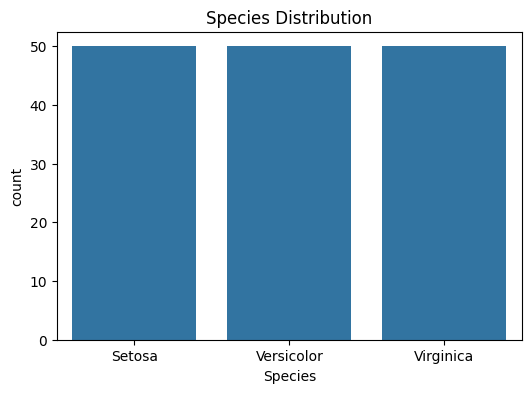

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Species")

plt.title("Species Distribution")

plt.show()

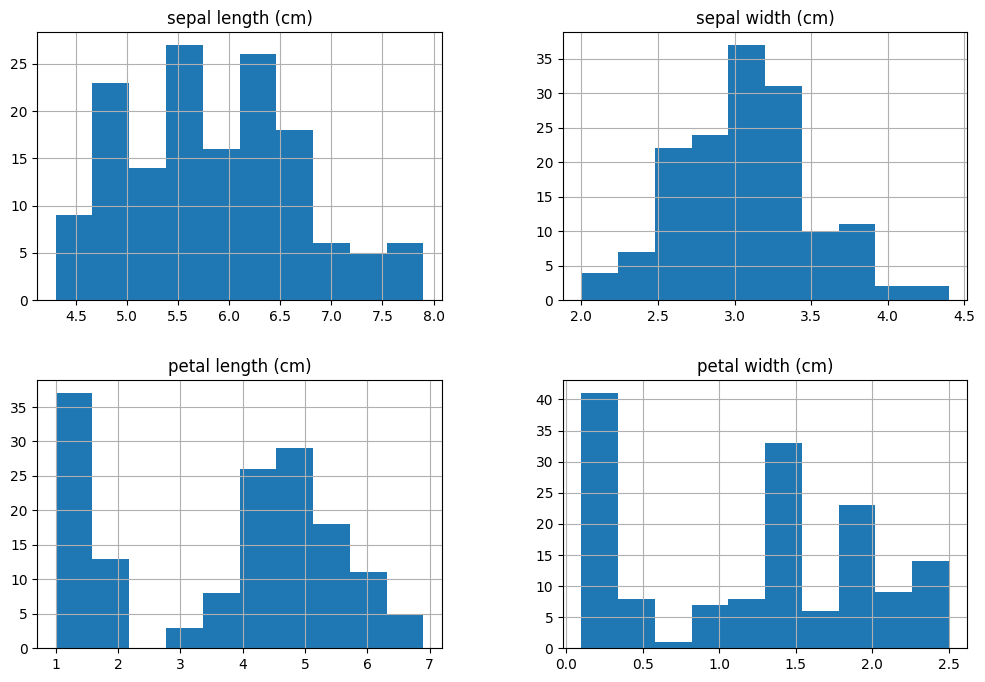

In [13]:
df.hist(figsize=(12,8))

plt.show()

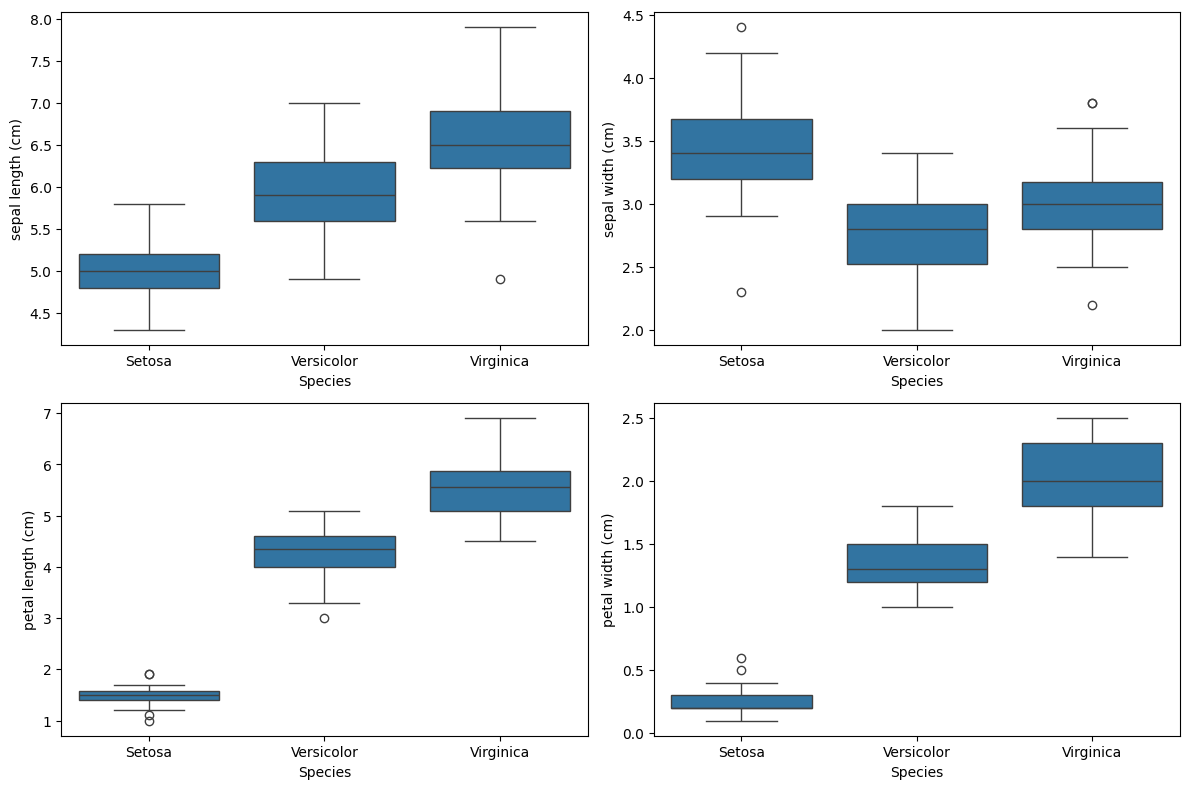

In [14]:
plt.figure(figsize=(12,8))

for i,column in enumerate(df.columns[:-1]):
    plt.subplot(2,2,i+1)
    sns.boxplot(x="Species",y=column,data=df)

plt.tight_layout()

plt.show()

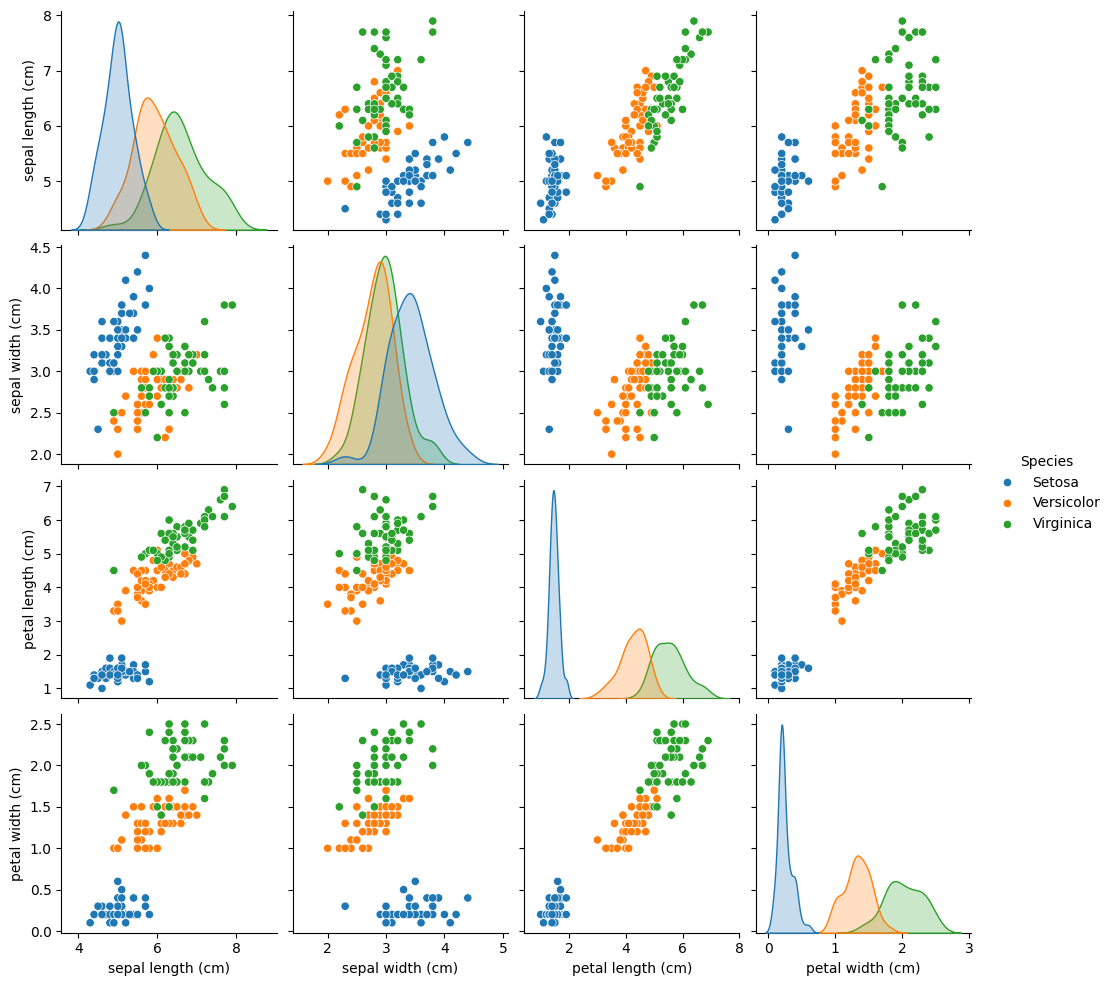

In [15]:
sns.pairplot(df,hue="Species")

plt.show()

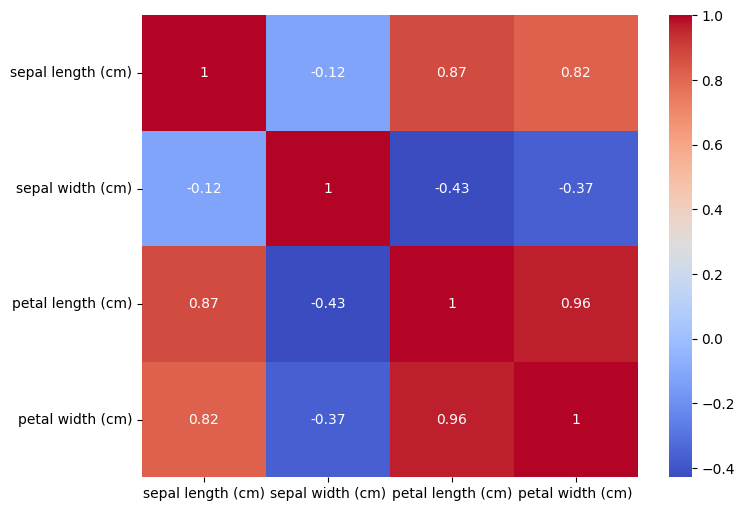

In [16]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop("Species",axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [17]:
X=df.drop("Species",axis=1)

y=df["Species"]

Train and test data spliting

In [18]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


## Train Machine Learning Models

### Model-1 (Logistic Regression)

In [20]:
lr=LogisticRegression()

lr.fit(X_train,y_train)

pred_lr=lr.predict(X_test)

In [21]:
accuracy_score(y_test,pred_lr)

1.0

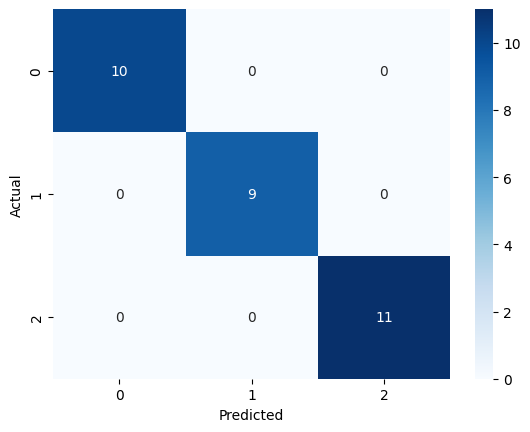

In [22]:
cm=confusion_matrix(y_test,pred_lr)

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [23]:
print(classification_report(y_test,pred_lr))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Model-2 (Decision Tree)

In [24]:
dt=DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

pred_dt=dt.predict(X_test)

In [25]:
accuracy_score(y_test,pred_dt)

1.0

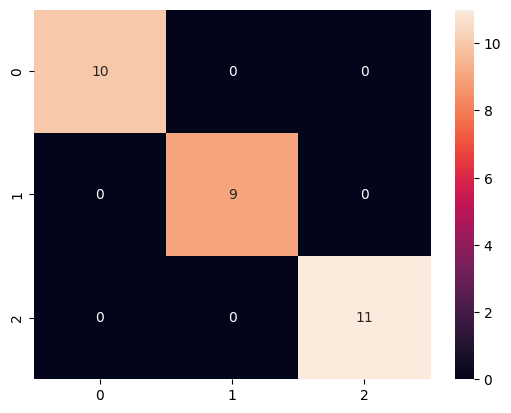

In [26]:
cm=confusion_matrix(y_test,pred_dt)

sns.heatmap(cm,annot=True,fmt='d')

plt.show()

In [27]:
print(classification_report(y_test,pred_dt))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Model 3 — (Random Forest)

In [28]:
rf=RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

pred_rf=rf.predict(X_test)

In [29]:
accuracy_score(y_test,pred_rf)

1.0

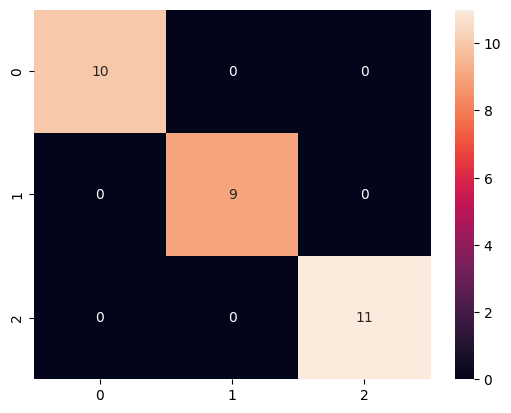

In [30]:
cm=confusion_matrix(y_test,pred_rf)

sns.heatmap(cm,annot=True,fmt='d')

plt.show()

In [31]:
print(classification_report(y_test,pred_rf))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Compare Models

In [32]:
results=pd.DataFrame({

"Model":[
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
],

"Accuracy":[
accuracy_score(y_test,pred_lr),
accuracy_score(y_test,pred_dt),
accuracy_score(y_test,pred_rf)
]

})

results

,Model,Accuracy
0,Logistic Regression,1.0
1,Decision Tree,1.0
2,Random Forest,1.0


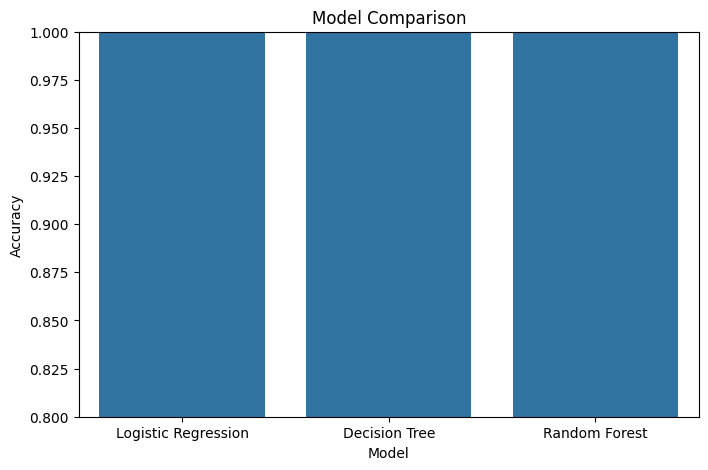

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(data=results,x="Model",y="Accuracy")

plt.ylim(0.8,1)

plt.title("Model Comparison")

plt.show()

Feature Importance

In [34]:
importance=pd.DataFrame({

"Feature":X.columns,

"Importance":rf.feature_importances_

})

importance=importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,petal length (cm),0.439994
3,petal width (cm),0.421522
0,sepal length (cm),0.108098
1,sepal width (cm),0.030387


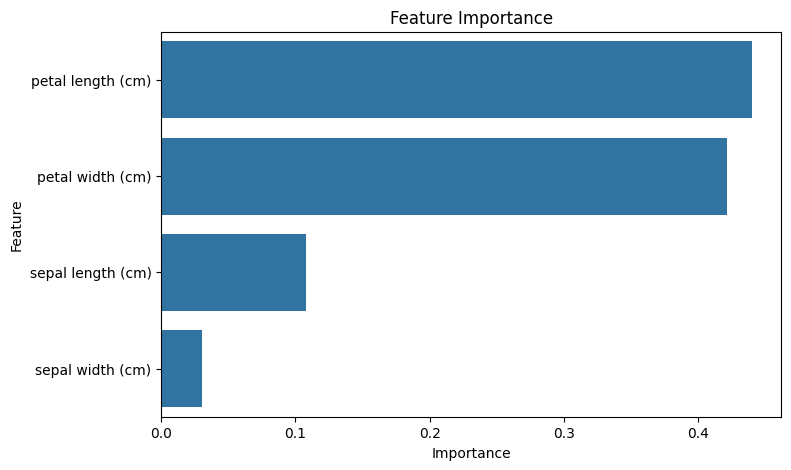

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

Prediction on New Data

In [36]:
sample=[[5.1,3.5,1.4,0.2]]

prediction=rf.predict(sample)

print(prediction)

['Setosa']


In [37]:
sample=[[6.5,3.0,5.5,2.0]]

prediction=rf.predict(sample)

print(prediction)

['Virginica']


## Conclusion

- The Iris dataset contains 150 samples equally distributed among three species.
- No missing values were found.
- Petal Length and Petal Width are the most important features.
- Three machine learning models were trained:
  - Logistic Regression
  - Decision Tree
  - Random Forest
- Random Forest achieved the highest accuracy (or tied for the highest, depending on the split), making it the preferred model for this classification task.
- The model can accurately classify Iris flowers based on their physical measurements.